In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression  #逻辑回归
from sklearn.ensemble import RandomForestClassifier 
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('clean_feature.csv')
train = pd.read_csv('train.csv')
X = data
y = train['Survived']

In [3]:
from sklearn.model_selection import cross_val_score

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y,stratify=y, test_size=0.25, random_state=42)

In [5]:
X_train['Age'] = X_train['Age'].fillna(X_train['Age'].median())

In [6]:
X['Age'] = X['Age'].fillna(X_train['Age'].median())

In [7]:
X.isnull().sum()

Unnamed: 0.1    0
Unnamed: 0      0
PassengerId     0
Pclass          0
Age             0
SibSp           0
Parch           0
Fare            0
Sex_female      0
Sex_male        0
Embarked_C      0
Embarked_Q      0
Embarked_S      0
dtype: int64

In [8]:
X_test['Age'] = X_test['Age'].fillna(X_test['Age'].median())   #为什么清洗时候没有把年龄给存进去

In [9]:
X.to_csv('clean_feature.csv')

In [10]:
X_train.isnull().sum()

Unnamed: 0.1    0
Unnamed: 0      0
PassengerId     0
Pclass          0
Age             0
SibSp           0
Parch           0
Fare            0
Sex_female      0
Sex_male        0
Embarked_C      0
Embarked_Q      0
Embarked_S      0
dtype: int64

In [11]:
X_test.isnull().sum()

Unnamed: 0.1    0
Unnamed: 0      0
PassengerId     0
Pclass          0
Age             0
SibSp           0
Parch           0
Fare            0
Sex_female      0
Sex_male        0
Embarked_C      0
Embarked_Q      0
Embarked_S      0
dtype: int64

In [13]:
lr = LogisticRegression(max_iter = 100)
lr.fit(X_train, y_train)
score = cross_val_score(lr,X_train,y_train,cv = 10)
score.mean()

/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation f

np.float64(0.7964269561284486)

In [15]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report   #导入混淆矩阵来评估分类的准确性

In [16]:
lr = LogisticRegression().fit(X_train,y_train)
y_pred = lr.predict(X_train)
confusion_matrix(y_train,y_pred, labels=[0,1])

/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([[360,  52],
       [ 80, 176]], dtype=int64)

In [17]:
y_train.value_counts(),360+52,80+176

(Survived
 0    412
 1    256
 Name: count, dtype: int64,
 412,
 256)

In [18]:
print(classification_report(y_train,y_pred))   #减少计算过程

              precision    recall  f1-score   support

           0       0.82      0.87      0.85       412
           1       0.77      0.69      0.73       256

    accuracy                           0.80       668
   macro avg       0.80      0.78      0.79       668
weighted avg       0.80      0.80      0.80       668



In [19]:
2/(1/0.82+1/0.87)

0.8442603550295857

In [21]:
176/(176+52)

0.7719298245614035

In [22]:
from sklearn.metrics import roc_curve

In [25]:
fpr,tpr,thresholds = roc_curve(y_test,lr.decision_function(X_test))
fpr,tpr,thresholds

(array([0.        , 0.        , 0.        , 0.00729927, 0.00729927,
        0.01459854, 0.01459854, 0.02919708, 0.02919708, 0.03649635,
        0.03649635, 0.04379562, 0.04379562, 0.05109489, 0.05109489,
        0.0729927 , 0.0729927 , 0.08029197, 0.08029197, 0.08759124,
        0.08759124, 0.09489051, 0.09489051, 0.10948905, 0.10948905,
        0.13138686, 0.13138686, 0.13868613, 0.13868613, 0.15328467,
        0.15328467, 0.18248175, 0.18248175, 0.22627737, 0.22627737,
        0.23357664, 0.23357664, 0.24817518, 0.24817518, 0.26277372,
        0.26277372, 0.27737226, 0.27737226, 0.33576642, 0.33576642,
        0.37226277, 0.37226277, 0.41605839, 0.41605839, 0.49635036,
        0.49635036, 0.55474453, 0.55474453, 0.61313869, 0.61313869,
        0.67153285, 0.67153285, 0.70072993, 0.70072993, 0.74452555,
        0.74452555, 0.80291971, 0.80291971, 0.81751825, 0.81751825,
        0.83211679, 0.83211679, 0.90510949, 0.90510949, 1.        ]),
 array([0.        , 0.01162791, 0.05813953, 0.

Text(0, 0.5, 'True Positive Rate')

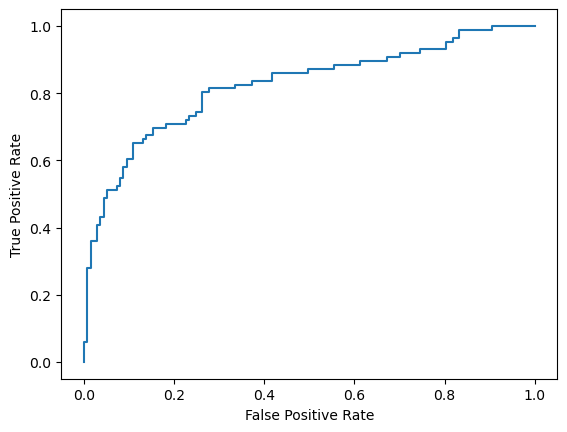

In [32]:
plt.plot(fpr,tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

Text(0.5, 1.0, 'LR ROC')

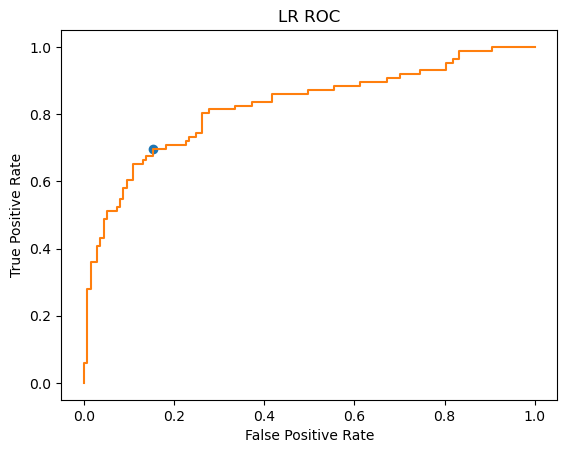

In [38]:
close_zero = np.argmin(np.abs(thresholds))
plt.plot(fpr[close_zero],tpr[close_zero],'o')
plt.plot(fpr,tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LR ROC')